# When does DoRA help?

**A controlled capacity study and a few-shot real-image proxy**  
Vladislav Lapin · MIPT FPMI / AI360 · AIRI Summer School 2026

## tl;dr

- In the additive rank-4 control, LoRA and DoRA both represent the target up to numerical precision.
- Under heterogeneous row-wise magnitude shift (`γ=0.8`), the best rank-4 additive LoRA residual is `0.292`, while a feasible DoRA construction remains at numerical zero.
- On real images at fixed rank 4, DoRA changes accuracy versus LoRA by `+0.33 pp` (contrast), `+0.67 pp` (rotation), and `+1.39 pp` (mixed shift).
- Magnitude-only adaptation is best for pure contrast, so DoRA is useful conditionally rather than universally.


## Context & Methods

The notebook is an executed companion to the scripts, not the primary training entrypoint. Raw runs are produced by `run_synthetic.py` and `run_digits.py`; this notebook checks their coverage and presents the saved evidence.

### Key assumptions

- The synthetic comparison measures representational capacity: LoRA receives its exact SVD optimum and DoRA receives a feasible construction using the known generative decomposition.
- The real-data benchmark is `sklearn Digits`, not an LLM reproduction.
- Five paired adaptation seeds share one fixed pretrained backbone.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image

ROOT = Path.cwd()
assert (ROOT / "results" / "key_metrics.json").exists(), "Run this notebook from the repository root."

key_metrics = json.loads((ROOT / "results" / "key_metrics.json").read_text())
key_metrics

{'base_clean_accuracy_pct': 97.5, 'rank4_dora_minus_lora_pp': {'contrast': 0.3333333333333388, 'mixed': 1.3888888888888906, 'rotation': 0.6666666666666532}, 'rank4_delta_ci95_pp': {'contrast': [-1.5144137976699221, 2.1810804643366], 'mixed': [0.07552343277226603, 2.702254345005515], 'rotation': [0.20392581580035596, 1.1294075175329503]}, 'mixed_validation_selected_accuracy_pct': {'DoRA': 76.72222222222223, 'Frozen': 50.83333333333333, 'Full fine-tuning': 73.33333333333333, 'LoRA': 75.27777777777777, 'Magnitude-only': 65.88888888888889}, 'synthetic_rank4_lora_error_at_gamma_08': 0.2923089176416397, 'synthetic_rank4_dora_error_at_gamma_08': 1.4510765709019324e-07, 'validation_status': 'ready_with_caveats', 'caveats': ['Small real-data proxy (sklearn Digits), not an LLM reproduction.', 'Five paired adaptation seeds with one fixed pretrained backbone.', 'Synthetic DoRA result is a feasible ground-truth construction; LoRA receives its exact SVD optimum.']}

## Data

### 1. Controlled capacity sweep

In [2]:
synthetic_runs = pd.read_csv(ROOT / "results" / "synthetic" / "synthetic_runs.csv")
assert synthetic_runs["seed"].nunique() == 10
assert set(synthetic_runs["rank"]) == {1, 2, 4, 8}
assert set(synthetic_runs["magnitude_strength"]) == {0.0, 0.2, 0.4, 0.6, 0.8}

capacity = pd.read_csv(ROOT / "results" / "synthetic" / "capacity_gap_summary.csv")
capacity.query("rank == 4")[
    ["magnitude_strength", "lora_relative_error_mean", "dora_relative_error_mean", "capacity_gap_log10_mean"]
].round(6)

,magnitude_strength,lora_relative_error_mean,dora_relative_error_mean,capacity_gap_log10_mean
10,0.0,0.000000,0.0,-0.036987
11,0.2,0.094785,0.0,5.816537
12,0.4,0.177590,0.0,6.093742
13,0.6,0.241552,0.0,6.245840
14,0.8,0.292309,0.0,6.311027


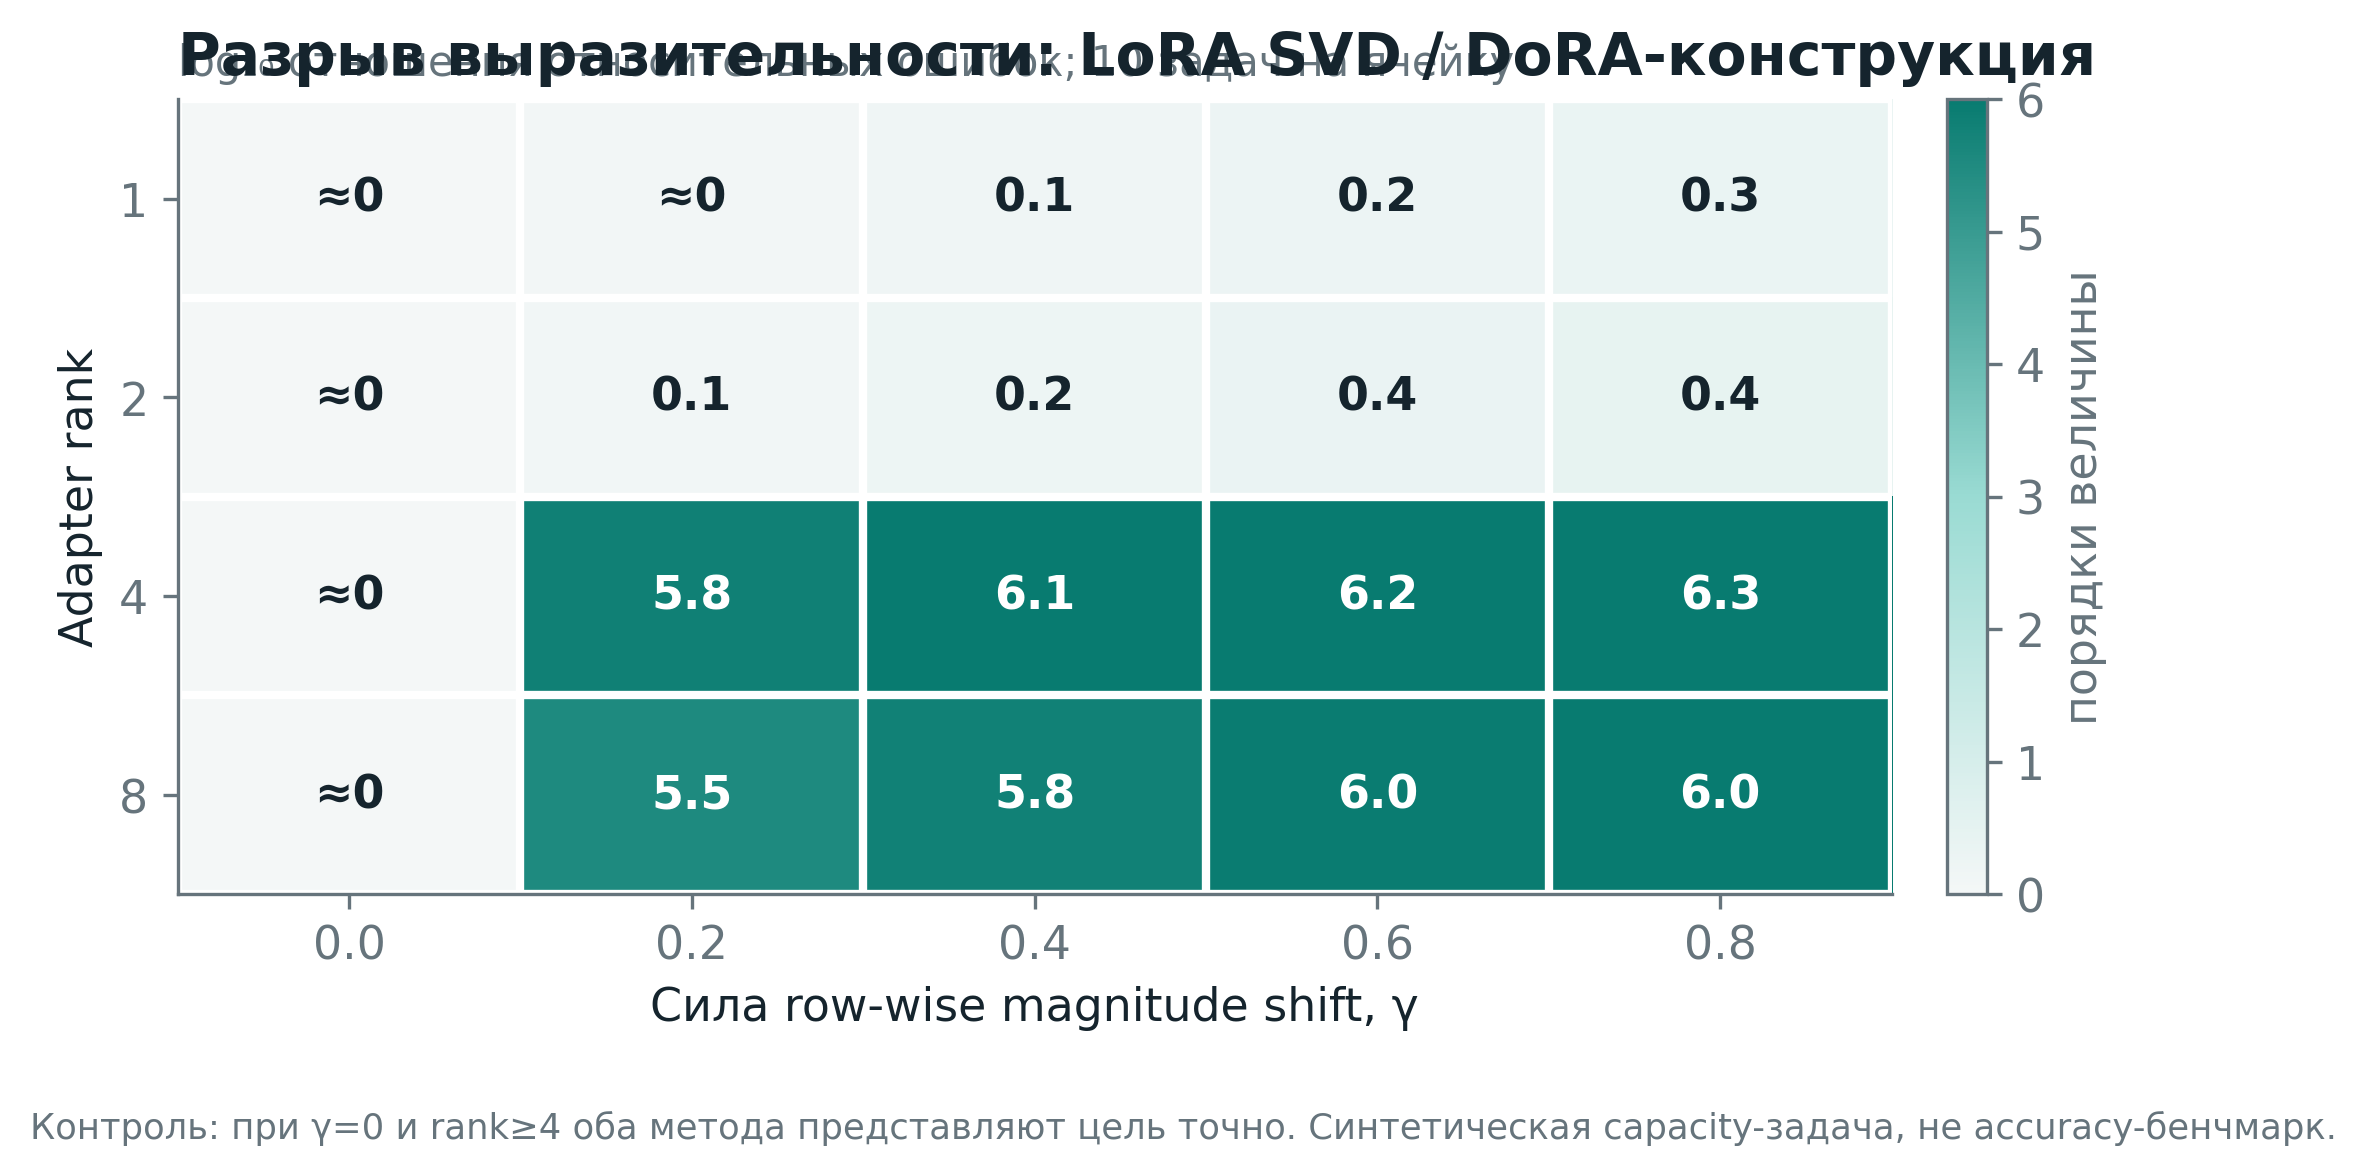

In [3]:
Image(filename=ROOT / "figures" / "synthetic_capacity_gap.png", width=850, embed=True)

### 2. Few-shot Digits domain adaptation

In [4]:
digit_runs = pd.read_csv(ROOT / "results" / "digits" / "digits_runs.csv")
adapter_runs = digit_runs[digit_runs["method"].isin(["LoRA", "DoRA"])]
coverage = adapter_runs.groupby(["scenario", "seed", "method"])["rank"].nunique()
assert (coverage == 4).all()
assert digit_runs["target_accuracy"].between(0, 1).all()

rank4 = pd.read_csv(ROOT / "results" / "digits" / "rank4_method_summary.csv")
rank4.pivot(index="scenario", columns="method", values="accuracy_mean_pct").round(2)

method,DoRA,Frozen,Full fine-tuning,LoRA,Magnitude-only
scenario,,,,,
contrast,95.06,77.50,96.39,94.72,97.00
mixed,74.72,50.83,73.33,73.33,65.89
rotation,93.94,51.67,93.22,93.28,86.50


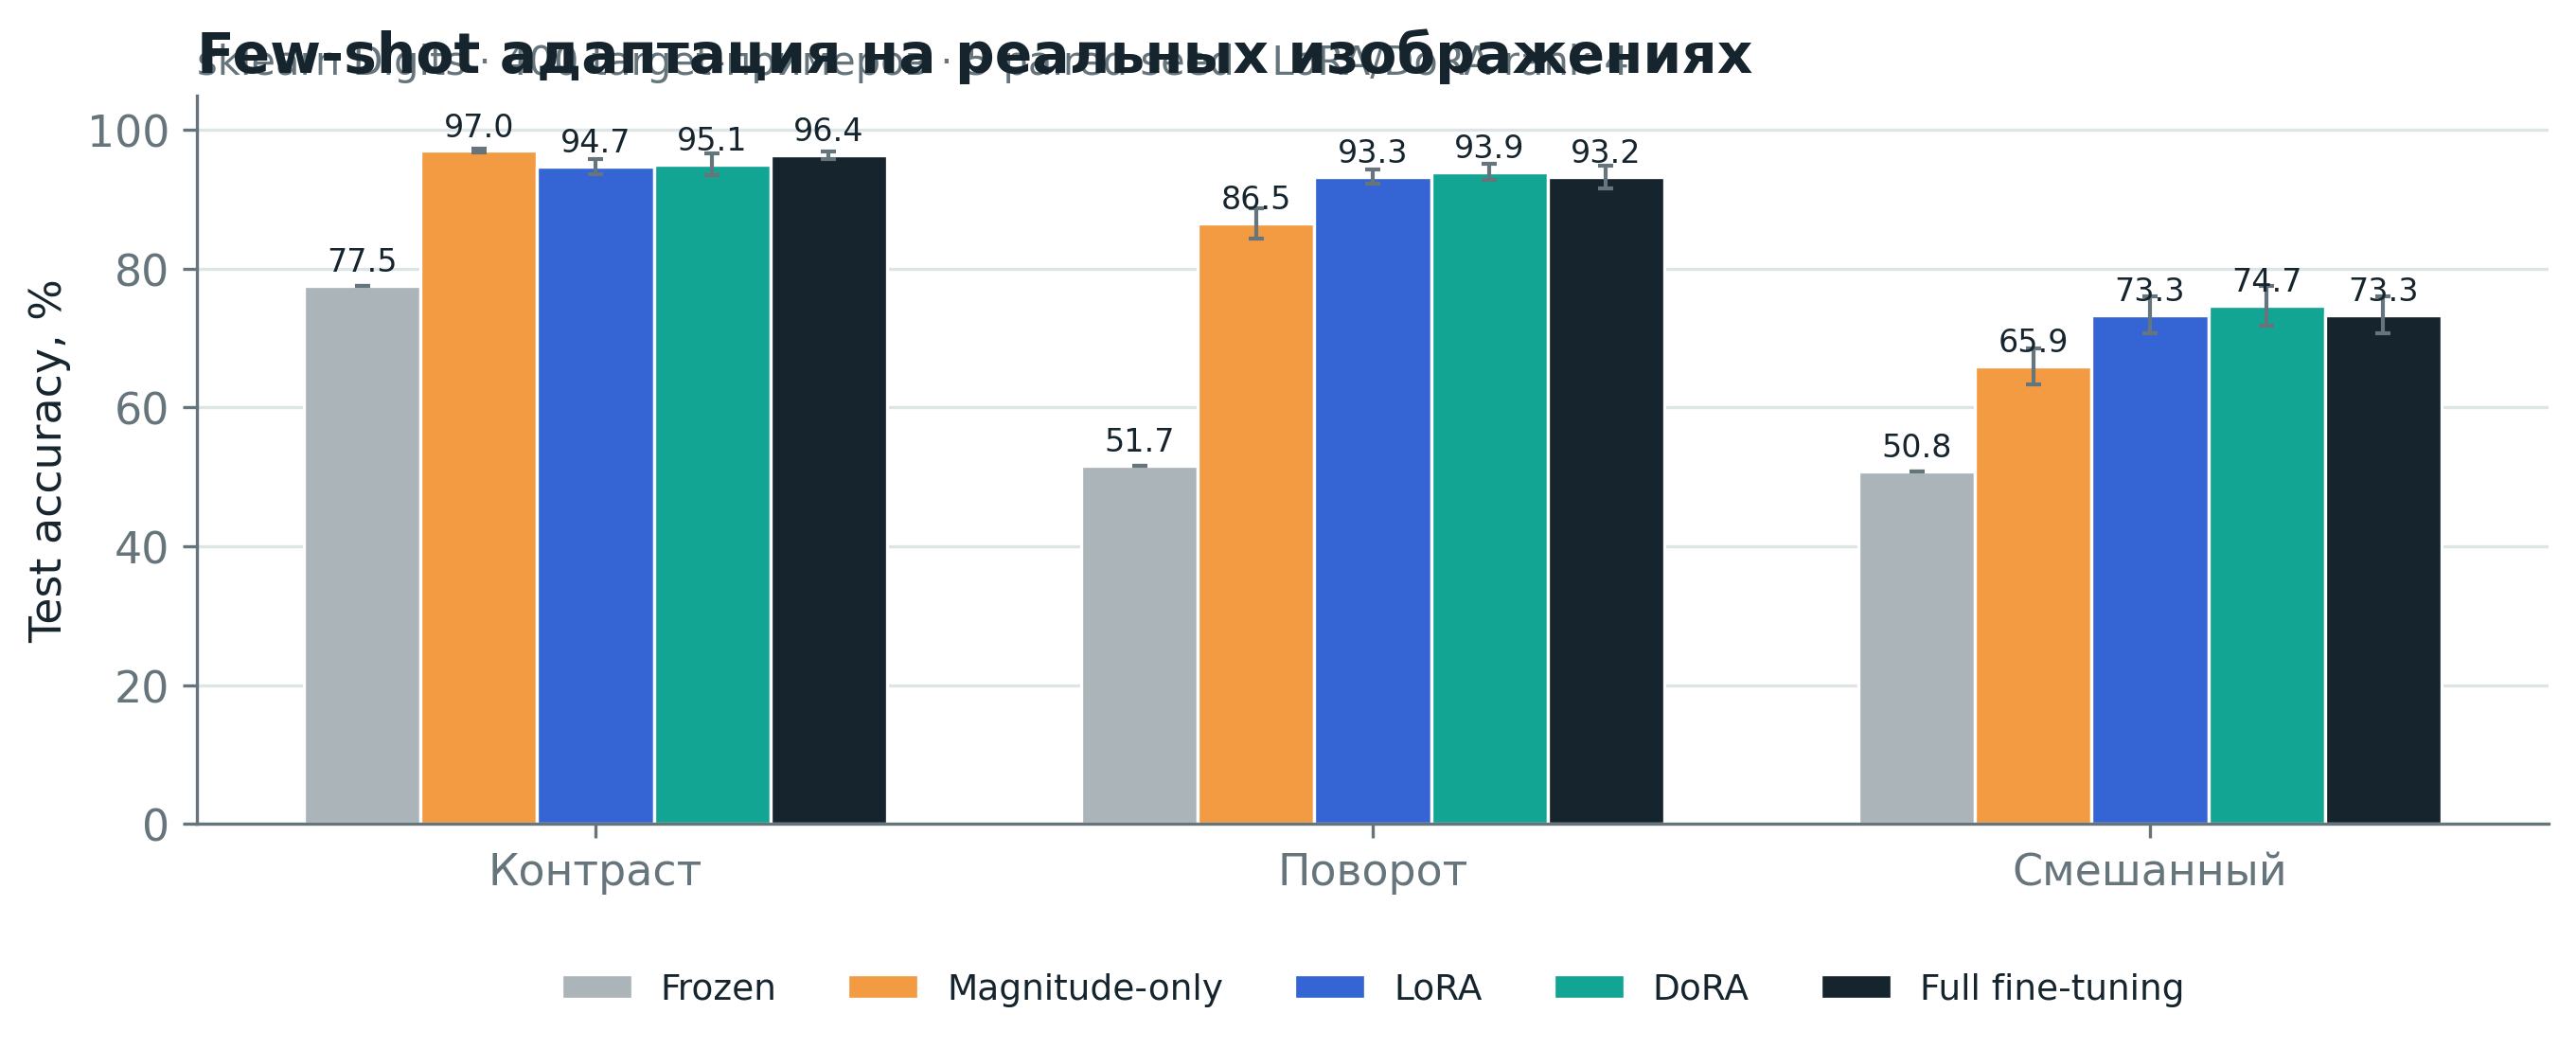

In [5]:
Image(filename=ROOT / "figures" / "digits_rank4_benchmark.png", width=950, embed=True)

## Results

### Paired DoRA − LoRA differences

In [6]:
paired = pd.read_csv(ROOT / "results" / "digits" / "paired_delta_summary.csv")
paired.assign(
    interval=paired.apply(lambda row: f"[{row.ci95_low_pp:.2f}, {row.ci95_high_pp:.2f}]", axis=1)
)[["scenario", "rank", "mean_delta_pp", "interval"]].round({"mean_delta_pp": 2})

,scenario,rank,mean_delta_pp,interval
0,contrast,1,0.28,"[-1.55, 2.10]"
1,contrast,2,0.50,"[-0.46, 1.46]"
2,contrast,4,0.33,"[-1.51, 2.18]"
3,contrast,8,0.67,"[-1.25, 2.58]"
4,mixed,1,2.72,"[-0.16, 5.60]"
5,mixed,2,0.28,"[-2.65, 3.20]"
6,mixed,4,1.39,"[0.08, 2.70]"
7,mixed,8,1.89,"[0.40, 3.38]"
8,rotation,1,0.83,"[-0.98, 2.64]"
9,rotation,2,0.50,"[-1.23, 2.23]"


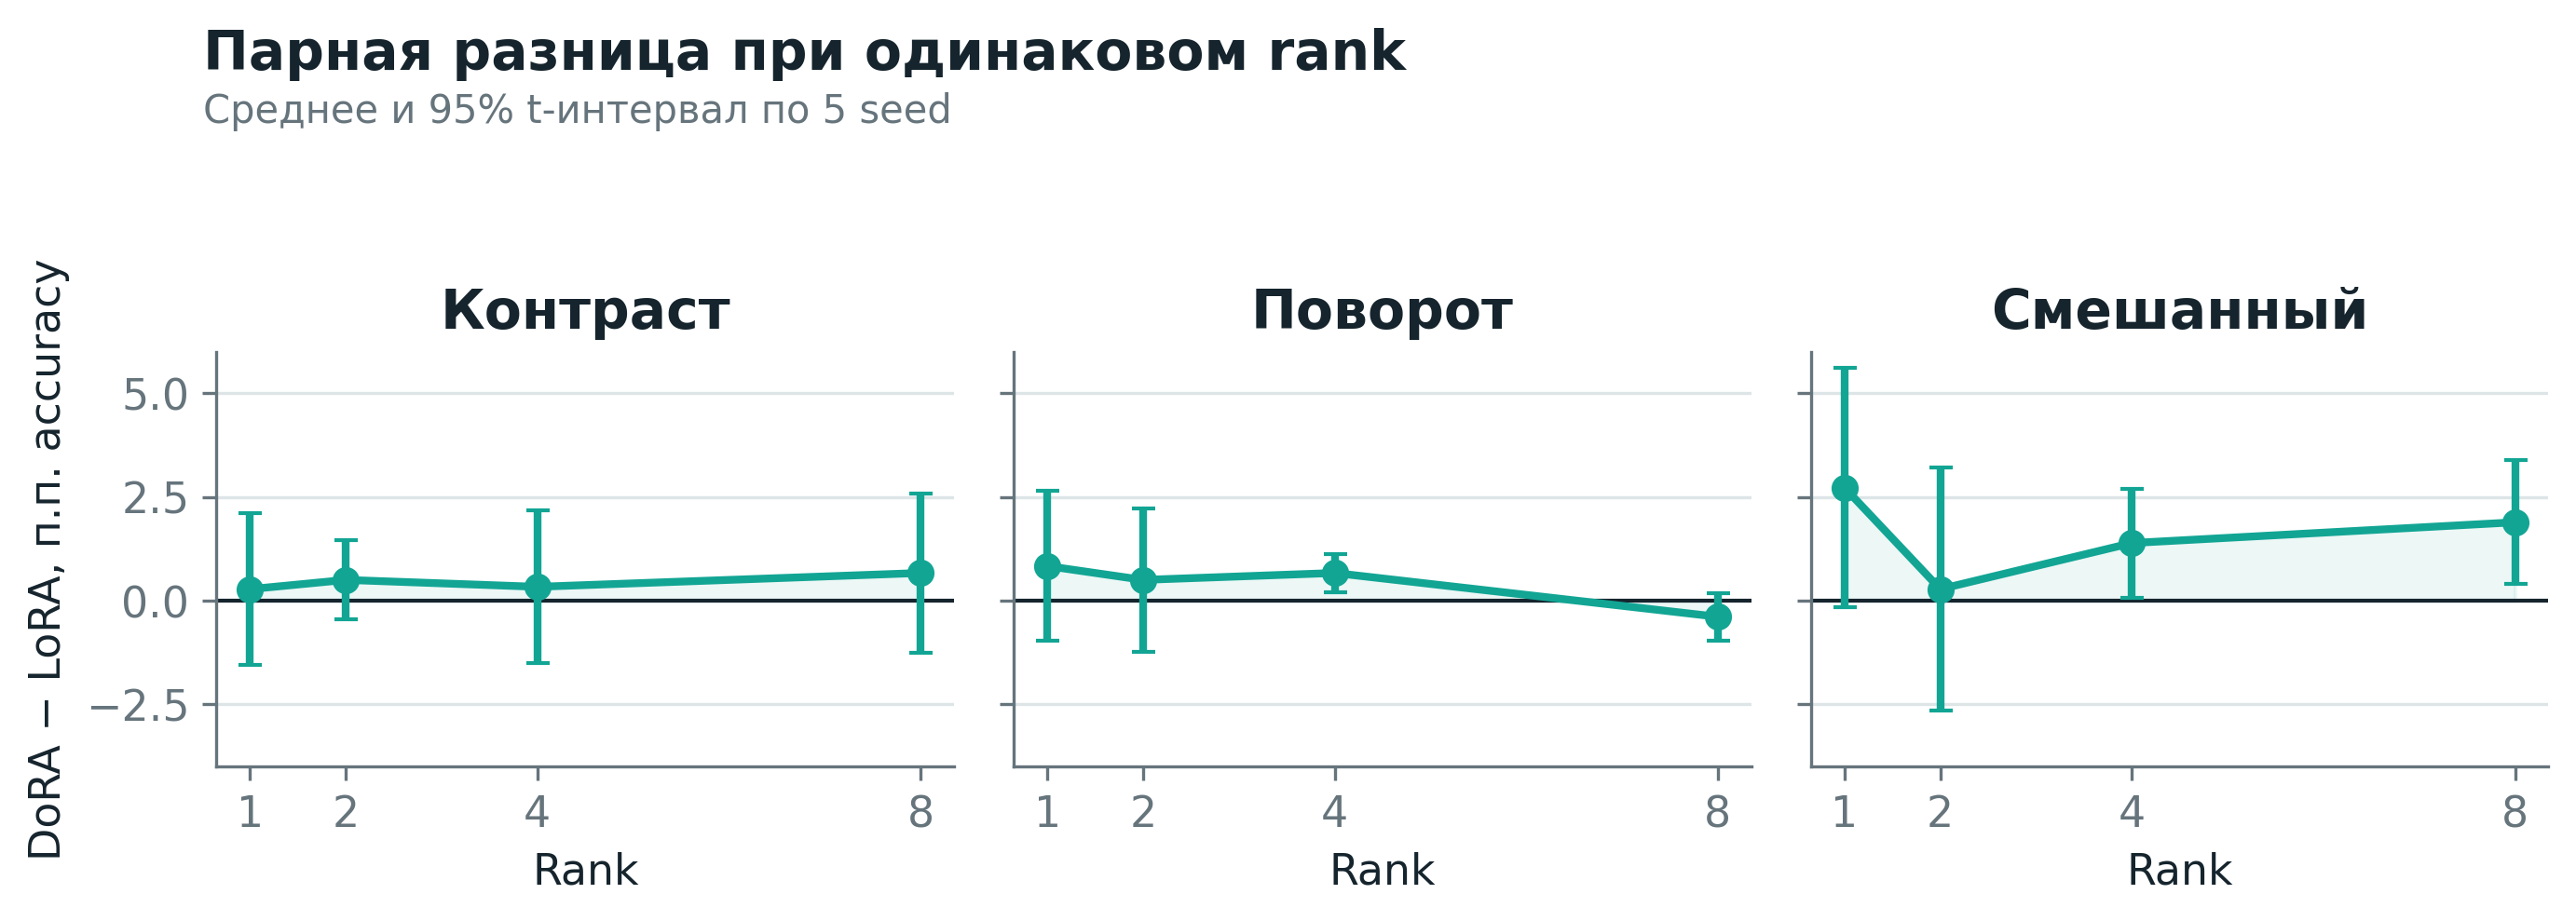

In [7]:
Image(filename=ROOT / "figures" / "digits_paired_delta.png", width=950, embed=True)

## Takeaways

1. **The old synthetic result needed a control.** At `γ=0`, rank-4 LoRA is already exact; DoRA's capacity advantage appears only when heterogeneous row scaling makes the additive update higher-rank.
2. **A capacity gap is not an accuracy gap.** Real-data gains are measured in percentage points, not orders of magnitude.
3. **DoRA is most convincing on the mixed shift.** At rank 4 the paired interval is positive, and validation-selected DoRA also leads the other trained methods.
4. **Simpler can be better.** Magnitude-only adaptation wins on pure contrast with 202 parameters.

## Limitations

- small real-image proxy and one fixed backbone;
- five paired adaptation seeds;
- known ground-truth decomposition in the synthetic capacity construction;
- no wall-clock comparison and no LLM/GLUE reproduction.

The next experiment should use the official PEFT implementation on a small pretrained transformer, with LoRA, DoRA, and rsLoRA evaluated under validation-tuned learning rates and matched target modules.
